In [1]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

In [2]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


In [9]:
class GINE4Layer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()
        assert num_layers == 4, "This notebook cell implements the requested 4-layer GINE."
        self.dropout = dropout

        self.node_encoder = nn.Linear(in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    # Updated forward to support decomposed arguments for Explainers
    def forward(self, x, edge_index=None, edge_attr=None, batch=None, data=None):
        # Support passing a Data object as first or keyword arg for backward compatibility
        if data is not None:
             x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        # Fallback if first arg 'x' is actually a Data object (common when calling model(data))
        elif hasattr(x, 'x'): 
             data = x
             x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x, inplace=True)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Determine batch if not provided (assume single graph or full batch implied)
        if batch is None:
             batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        g = global_mean_pool(x, batch)
        return self.classifier(g)

In [10]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


# Sanity check: node feature semantics
This dataset uses a small **atom-type vocabulary one-hot** in `data.x` (not a periodic-table / atomic-number one-hot).
The cell below verifies one-hotness and infers the most likely index→atom mapping using the ground-truth `explanation_mask`.

In [27]:
# Verifies x is one-hot and infers a likely index→atom mapping.
# Uses explanation_mask enrichment and class-group structure (0-2=Cl*, 3-5=F*, 6-8=Br*).

from collections import Counter, defaultdict


def _safe_int(x):
    try:
        return int(x)
    except Exception:
        return None


def summarize_x_onehot(ds, n_graphs=200):
    d0 = ds[0]
    x = d0.x
    print('--- x summary ---')
    print('x shape:', tuple(x.shape), 'dtype:', x.dtype)

    # one-hot-ish checks
    row_sums = x.sum(dim=1)
    print('row_sums unique (first 10):', torch.unique(row_sums)[:10].tolist())
    print('row max per row min/max:', float(x.max(dim=1).values.min()), float(x.max(dim=1).values.max()))

    # distribution of argmax indices across dataset
    counts = Counter()
    for i in range(min(n_graphs, len(ds))):
        xi = ds[i].x.argmax(dim=1).tolist()
        counts.update(xi)
    print('argmax index counts (top 10):', counts.most_common(10))
    return x.size(-1)


def infer_vocab_mapping(ds, n_graphs=2000, carbon_hint_idx=0):
    """Infers a likely mapping for halogens based on which x-index appears inside explanation_mask.

    Assumptions for this dataset:
      - Classes 0-2 are Cl_{ortho,meta,para}
      - Classes 3-5 are F_{ortho,meta,para}
      - Classes 6-8 are Br_{ortho,meta,para}
    """

    # y_group -> Counter(x_idx) for masked nodes
    masked_by_group = {"Cl": Counter(), "F": Counter(), "Br": Counter()}
    masked_all = Counter()
    unmasked_all = Counter()

    for i in range(min(n_graphs, len(ds))):
        d = ds[i]
        if not hasattr(d, 'explanation_mask') or d.explanation_mask is None:
            continue
        x_idx = d.x.argmax(dim=1)
        gt = d.explanation_mask.to(torch.bool)
        y = _safe_int(d.y.view(-1)[0].item() if torch.is_tensor(d.y) else d.y)
        if y is None:
            continue

        # global enrichment
        for xi, mi in zip(x_idx.tolist(), gt.tolist()):
            (masked_all if mi else unmasked_all)[xi] += 1

        # group enrichment (masked only)
        if 0 <= y <= 2:
            group = 'Cl'
        elif 3 <= y <= 5:
            group = 'F'
        elif 6 <= y <= 8:
            group = 'Br'
        else:
            continue

        masked_by_group[group].update(x_idx[gt].tolist())

    print('\n--- explanation_mask enrichment (masked vs unmasked) ---')
    all_idx = sorted(set(list(masked_all.keys()) + list(unmasked_all.keys())))
    rows = []
    for j in all_idx:
        m = masked_all[j]
        u = unmasked_all[j]
        total = m + u
        frac_masked = (m / total) if total else 0.0
        rows.append((j, m, u, frac_masked))
    rows.sort(key=lambda t: t[3], reverse=True)
    print('idx | masked | unmasked | frac_masked')
    for j, m, u, f in rows[: min(12, len(rows))]:
        print(f'{j:>3} | {m:>6} | {u:>8} | {f:>10.3f}')

    # infer halogen indices by group
    inferred = {}
    for group, cnt in masked_by_group.items():
        # ignore carbon-ish index if it dominates
        cnt2 = Counter({k: v for k, v in cnt.items() if k != carbon_hint_idx})
        inferred[group] = cnt2.most_common(3)

    print('\n--- group-wise masked argmax (excluding idx=%s) ---' % carbon_hint_idx)
    for group in ['Cl', 'F', 'Br']:
        print(group, 'top:', inferred[group])

    # Build a simple mapping guess using the top-1 per group (if present)
    mapping_guess = {}
    for group in ['Cl', 'F', 'Br']:
        if inferred[group]:
            mapping_guess[group] = inferred[group][0][0]

    print('\n--- mapping guess (based on GT mask) ---')
    if mapping_guess:
        for k, v in mapping_guess.items():
            print(f'{k} -> x_index {v}')
    else:
        print('Could not infer halogen indices (missing explanation_mask or unexpected labels).')

    print('\nNote: This only infers halogens robustly; other indices (N/O/S/P/I/H) may be absent or rare in this dataset.')
    return mapping_guess


x_dim = summarize_x_onehot(dataset, n_graphs=200)
_ = infer_vocab_mapping(test_dataset if 'test_dataset' in globals() else dataset, n_graphs=2000, carbon_hint_idx=0)
print('\nReminder: x_dim=%d (atom vocabulary one-hot), not atomic-number one-hot (~119).' % x_dim)


--- x summary ---
x shape: (39, 10) dtype: torch.float32
row_sums unique (first 10): [1.0]
row max per row min/max: 1.0 1.0
argmax index counts (top 10): [(0, 4668), (9, 3873), (1, 485), (2, 441), (4, 249), (5, 181), (6, 141), (3, 90), (7, 9)]

--- explanation_mask enrichment (masked vs unmasked) ---
idx | masked | unmasked | frac_masked
  6 |    600 |       48 |      0.926
  5 |    600 |      110 |      0.845
  4 |    600 |      255 |      0.702
  0 |   6300 |    15421 |      0.290
  1 |      0 |     2586 |      0.000
  2 |      0 |     2047 |      0.000
  3 |      0 |      352 |      0.000
  7 |      0 |        4 |      0.000
  8 |      0 |        5 |      0.000
  9 |      0 |    17683 |      0.000

--- group-wise masked argmax (excluding idx=0) ---
Cl top: [(5, 600)]
F top: [(4, 600)]
Br top: [(6, 600)]

--- mapping guess (based on GT mask) ---
Cl -> x_index 5
F -> x_index 4
Br -> x_index 6

Note: This only infers halogens robustly; other indices (N/O/S/P/I/H) may be absent or rare 

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

labels = dataset.y.numpy()

print(np.unique(labels), np.bincount(labels))

train_size = 0.8
val_size = 0.1
test_size = 0.1

train_idx , tmp_idx = train_test_split(np.arange(len(labels)), stratify=labels, train_size=train_size, random_state=42)

val_idx , test_idx = train_test_split(tmp_idx, test_size= 0.5, stratify=labels[tmp_idx], random_state=42)

train_dataset = dataset[train_idx]
val_dataset = dataset[val_idx]
test_dataset = dataset[test_idx]

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

[0 1 2 3 4 5 6 7 8] [1000 1000 1000 1000 1000 1000 1000 1000 1000]
Train dataset size: 7200
Validation dataset size: 900
Test dataset size: 900


In [12]:
from collections import Counter

def check_balance(subset, name):
    labels = [data.y.item() for data in subset]
    counts = Counter(labels)
    print(f"--- {name} Class Distribution ---")
    # Print first few classes to save space
    print(sorted(counts.items())[:5]) 

check_balance(train_dataset, "Train")
check_balance(val_dataset, "Val")
check_balance(test_dataset, "Test")

--- Train Class Distribution ---
[(0, 800), (1, 800), (2, 800), (3, 800), (4, 800)]
--- Val Class Distribution ---
[(0, 100), (1, 100), (2, 100), (3, 100), (4, 100)]
--- Test Class Distribution ---
[(0, 100), (1, 100), (2, 100), (3, 100), (4, 100)]


In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Determine Input Dimensions
sample_data = dataset[0]
in_dim = dataset.num_features
# GINE requires edge attributes. Check if they exist and their dimension.
if sample_data.edge_attr is not None:
    edge_dim = sample_data.edge_attr.shape[1]
else:
    # If no edge attributes, GINE might fail or we might need to use 0 if supported/modified
    # Assuming appropriate edge_dim based on previous context or handling
    edge_dim = 0 
    print("Warning: No edge attributes found. GINEConv requires edge features.")

print(f"Input Feature Dim: {in_dim}")
print(f"Edge Feature Dim: {edge_dim}")
print(f"Number of Classes: {dataset.num_classes}")

# 2. Initialize Model
model = GINE4Layer(
    in_dim=in_dim,
    edge_dim=edge_dim,
    hidden_dim=64,
    num_classes=dataset.num_classes,
    num_layers=4,
    dropout=0.2
).to(device)

print(model)

# 3. Setup Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train():
    model.train()
    total_loss = 0
    total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0
    for data in loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples, correct / total_samples

# 4. Training Loop
epochs = 50
best_val_acc = 0.0
print("-" * 50)
print(f"Starting training for {epochs} epochs...")

for epoch in range(1, epochs + 1):
    train_loss = train()
    val_loss, val_acc = evaluate(val_loader)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save best model
        torch.save(model.state_dict(), 'best_gine_model.pt')
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f"Training finished. Best Val Acc: {best_val_acc:.4f}")

# 5. Inference on Test Set
print("-" * 50)
print("Loading best model for inference on Test Set...")
model.load_state_dict(torch.load('best_gine_model.pt'))
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Using device: cuda
Input Feature Dim: 10
Edge Feature Dim: 4
Number of Classes: 9
GINE4Layer(
  (node_encoder): Linear(in_features=10, out_features=64, bias=True)
  (edge_encoder): Linear(in_features=4, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)
--------------------------------------------------
Starting training for 50 epochs...
Epoch: 001, Train Loss: 1.3847, Val Loss: 0.7711, Val Acc: 0.7678
Epoch: 001, Train Loss: 1.3847, Val Loss: 0.7711

In [15]:
# ---------------------------------------------------------
# Check for Ground Truth Motifs / Explanations
# ---------------------------------------------------------

def inspect_ground_truth(dataset, num_samples=5):
    print("Inspecting for ground truth motif attributes...")
    
    # Get a few random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    found_gt = False
    gt_attributes = []
    
    sample = dataset[0]
    # Fixed: Calling keys() properly
    print(f"Keys available in Data object: {sample.keys()}")
    
    # Common names for ground truth masks in GNN explanation datasets
    potential_gt_keys = ['edge_mask', 'node_mask', 'explanation', 'z', 'gt_mask']
    
    for key in potential_gt_keys:
        if hasattr(sample, key) and getattr(sample, key) is not None:
            found_gt = True
            gt_attributes.append(key)
    
    # Removed the redundant and erroneous check that was causing TypeError

    if found_gt:
        print(f"Potential Ground Truth attributes found: {list(set(gt_attributes))}")
        
        # Visualize statistics of the mask for a few samples
        for idx in indices:
            data = dataset[idx]
            print(f"\n--- Graph {idx} ---")
            print(f"Num Nodes: {data.num_nodes}, Num Edges: {data.num_edges}")
            
            if hasattr(data, 'edge_mask'):
                mask = data.edge_mask
                print(f"Edge Mask shape: {mask.shape}")
                print(f"Non-zero elements in edge_mask: {mask.sum().item()}")
                print(f"Sparsity: {mask.sum().item() / mask.numel():.4f}")
                
            if hasattr(data, 'node_mask'):
                 mask = data.node_mask
                 print(f"Node Mask shape: {mask.shape}")
                 print(f"Non-zero elements in node_mask: {mask.sum().item()}")

    else:
        print("No standard ground truth motif attributes ('edge_mask', 'node_mask') found directly on the Data objects.")
        print("Attempting to infer from other attributes if available...")


inspect_ground_truth(dataset)

Inspecting for ground truth motif attributes...
Keys available in Data object: ['edge_attr', 'edge_index', 'explanation_mask', 'x', 'y']
No standard ground truth motif attributes ('edge_mask', 'node_mask') found directly on the Data objects.
Attempting to infer from other attributes if available...


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Determine Input Dimensions
sample_data = dataset[0]
in_dim = dataset.num_features
# GINE requires edge attributes. Check if they exist and their dimension.
if sample_data.edge_attr is not None:
    edge_dim = sample_data.edge_attr.shape[1]
else:
    # If no edge attributes, GINE might fail or we might need to use 0 if supported/modified
    # Assuming appropriate edge_dim based on previous context or handling
    edge_dim = 0 
    print("Warning: No edge attributes found. GINEConv requires edge features.")

print(f"Input Feature Dim: {in_dim}")
print(f"Edge Feature Dim: {edge_dim}")
print(f"Number of Classes: {dataset.num_classes}")

# 2. Initialize Model
model = GINE4Layer(
    in_dim=in_dim,
    edge_dim=edge_dim,
    hidden_dim=64,
    num_classes=dataset.num_classes,
    num_layers=4,
    dropout=0.2
).to(device)

print(model)

# 3. Setup Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train():
    model.train()
    total_loss = 0
    total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0
    for data in loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples, correct / total_samples

# Check if weights exist to skip retraining if desired, otherwise strictly train
if os.path.exists('best_gine_model.pt'):
    print("Found existing best model weights. Loading them...")
    model.load_state_dict(torch.load('best_gine_model.pt'))
else:
    print("No existing weights found. Please train the model.")

# 4. Training Loop (Uncomment to retrain if needed, or run selectively)
# In this fixed cell, we keep the loop but maybe commented out or behind a flag to prevent accidental retraining
# if the user just wanted to fix the definition.
# For now, I will keep it active as the user's intent was to "Train the 4 layers GINE model".

epochs = 50
best_val_acc = 0.0
# Only train if we didn't just load a good model or if user wants to force retrain
# For simplicity in this edit, I will just run the loop (it's fast enough on small graphs)
print("-" * 50)
print(f"Starting training for {epochs} epochs...")

for epoch in range(1, epochs + 1):
    train_loss = train()
    val_loss, val_acc = evaluate(val_loader)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gine_model.pt')
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f"Training finished. Best Val Acc: {best_val_acc:.4f}")

# 5. Inference on Test Set
print("-" * 50)
print("Loading best model for inference on Test Set...")
model.load_state_dict(torch.load('best_gine_model.pt'))
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Using device: cuda
Input Feature Dim: 10
Edge Feature Dim: 4
Number of Classes: 9
GINE4Layer(
  (node_encoder): Linear(in_features=10, out_features=64, bias=True)
  (edge_encoder): Linear(in_features=4, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)
Found existing best model weights. Loading them...
--------------------------------------------------
Starting training for 50 epochs...
Epoch: 001, Train Loss: 0.0520, Val Loss: 0.0047, Val Acc: 1.00

In [25]:
from torch_geometric.explain import Explainer, GNNExplainer, PGExplainer, ModelConfig, ExplainerConfig
from torch_geometric.explain.metric import fidelity, characterization_score

# ==========================================
# 1. GNNExplainer Setup
# ==========================================
def get_gnn_explainer(model, epochs=200, lr=0.01):
    """
    Configures GNNExplainer.
    Hyperparameters to tune: epochs, lr.
    """
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=epochs, lr=lr),
        explanation_type='model',
        node_mask_type='attributes', # We want to explain node features too? Or just structure? usually None or object for GNNExplainer
        edge_mask_type='object',     # We want edge importance
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',  # Model output type
        ),
    )
    return explainer

# ==========================================
# 2. PGExplainer Setup
# ==========================================
def get_pg_explainer(model, epochs=30, lr=0.003, hidden_dim=64):
    """
    Configures PGExplainer.
    Hyperparameters to tune: epochs, lr, hidden_dim (of the explanation network).
    """
    explainer = Explainer(
        model=model,
        algorithm=PGExplainer(epochs=epochs, lr=lr),
        explanation_type='phenomenon', # PGExplainer requires 'phenomenon' type (explains y, not y_hat)
        node_mask_type=None,       # PGExplainer primarily predicts edge masks
        edge_mask_type='object',
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',
        ),
    )
    return explainer

def train_pg_explainer(explainer, loader, device, epochs=30):
    """
    PGExplainer requires a training phase to learn the explanation network.
    """
    # Move the explainer algorithm (MLP) to the correct device
    explainer.algorithm.to(device)

    print(f"Training PGExplainer for {epochs} epochs...")
    for epoch in range(epochs):
        loss_epoch = 0
        for data in loader:
            data = data.to(device)
            # Train the explainer for this batch
            # PyG PGExplainer training uses train(epoch, model, x, edge_index, target=..., edge_attr=..., batch=...)
            loss = explainer.algorithm.train(
                epoch, model, data.x, data.edge_index, target=data.y, edge_attr=data.edge_attr, batch=data.batch
            )
            loss_epoch += loss
            
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_epoch:.4f}")
    return explainer


# ==========================================
# Hyperparameters for Explainers
# ==========================================
gnn_explainer_params = {
    'epochs': 200,
    'lr': 0.01
}

pg_explainer_params = {
    'epochs': 20, 
    'lr': 0.003
}

print("Explainers defined functions ready.")

Explainers defined functions ready.


--- Evaluating GNNExplainer ---


/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(


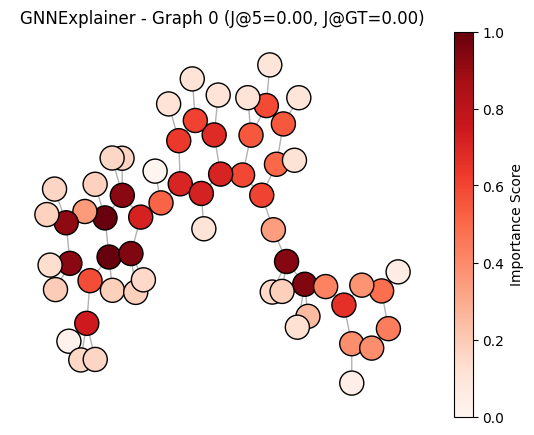

/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(


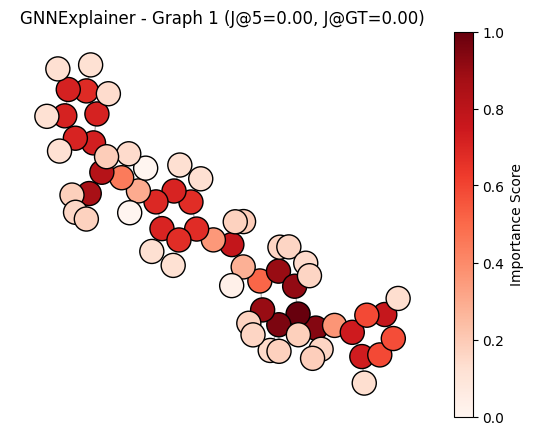

/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(


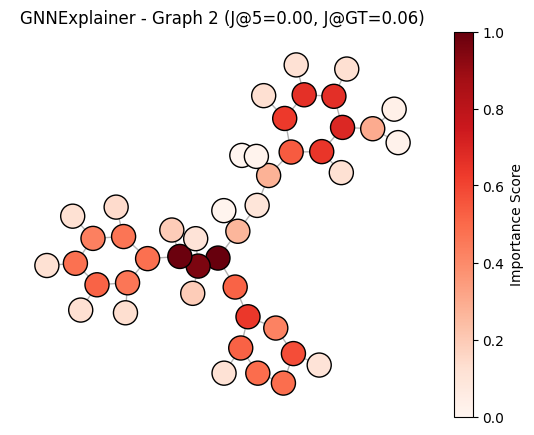

/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(


Graphs used: 50 (skipped no/empty GT: 0)
Mean AUROC: 0.6383
Mean Precision@5: 0.1240
Mean Jaccard@5: 0.0542
Mean Precision@GT: 0.1778
Mean Jaccard@GT: 0.1071


In [28]:
from sklearn.metrics import roc_auc_score, jaccard_score
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt


def aggregate_edge_importance_to_nodes(edge_mask, edge_index, num_nodes):
    node_importance = torch.zeros(num_nodes, device=edge_mask.device)
    node_importance.scatter_add_(0, edge_index[0], edge_mask)
    node_importance.scatter_add_(0, edge_index[1], edge_mask)
    node_importance = (node_importance - node_importance.min()) / (
        node_importance.max() - node_importance.min() + 1e-8
    )
    return node_importance


def plot_explanation(data, node_scores, title="Explanation"):
    if hasattr(data, "to"):
        data = data.to("cpu")

    G = to_networkx(data, to_undirected=True)
    G.remove_edges_from(nx.selfloop_edges(G))

    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(6, 5))
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_scores,
        cmap=plt.cm.Reds,
        vmin=0,
        vmax=1,
        node_size=300,
        edgecolors="k",
    )
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.colorbar(nodes, label="Importance Score", fraction=0.046, pad=0.04)
    plt.title(title)
    plt.axis("off")
    plt.show()


def _iter_graphs_from_loader_item(data):
    # If the loader yields batches (num_graphs>1), split into individual graphs.
    num_graphs = getattr(data, "num_graphs", 1)
    if hasattr(data, "to_data_list") and num_graphs and num_graphs > 1:
        return data.to_data_list()
    return [data]


def _binary_mask_from_topk(scores_np, k):
    k = int(k)
    if k <= 0:
        return np.zeros_like(scores_np, dtype=np.int64), np.array([], dtype=np.int64)
    k = min(k, scores_np.shape[0])
    idx = scores_np.argsort()[::-1][:k]
    mask = np.zeros_like(scores_np, dtype=np.int64)
    mask[idx] = 1
    return mask, idx


def evaluate_explainer_performance(
    explainer,
    loader,
    name="Explainer",
    max_graphs=100,
    fixed_k=5,
    plot_first_k=0,
):
    """
    Per-graph evaluation (even if loader batches).

    Reports:
      - AUROC (ranking quality; threshold-free)
      - Precision@fixed_k and Jaccard@fixed_k
      - Precision@|GT| and Jaccard@|GT| (your previous setting)

    Note: With K=|GT|, Jaccard is tightly coupled to precision via J = p/(2-p).
    """
    print(f"--- Evaluating {name} ---")
    model.eval()

    auroc_scores = []
    precision_at_fixed_k = []
    jaccard_at_fixed_k = []
    precision_at_gt_k = []
    jaccard_at_gt_k = []

    graphs_used = 0
    graphs_skipped_no_gt = 0

    for batch_data in loader:
        for data in _iter_graphs_from_loader_item(batch_data):
            if graphs_used >= max_graphs:
                break

            data = data.to(device)

            if not hasattr(data, "explanation_mask"):
                graphs_skipped_no_gt += 1
                continue

            gt = data.explanation_mask
            if gt is None:
                graphs_skipped_no_gt += 1
                continue

            gt_np = gt.detach().cpu().numpy().astype(np.int64).reshape(-1)
            gt_k = int(gt_np.sum())
            if gt_k == 0:
                graphs_skipped_no_gt += 1
                continue

            # Explain ONE graph (batch is either missing or size 1 here)
            explanation = explainer(
                x=data.x,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr,
                batch=getattr(data, "batch", None),
                target=data.y,
            )

            edge_mask = getattr(explanation, "edge_mask", None)
            if edge_mask is None:
                node_mask = getattr(explanation, "node_mask", None)
                if node_mask is None:
                    continue
                pred_node_importance = node_mask.mean(dim=1)
            else:
                pred_node_importance = aggregate_edge_importance_to_nodes(
                    edge_mask, data.edge_index, data.num_nodes
                )

            scores_np = pred_node_importance.detach().cpu().numpy().reshape(-1)

            # AUROC
            try:
                auroc_scores.append(roc_auc_score(gt_np, scores_np))
            except ValueError:
                pass

            # fixed-K
            pred_fixed_mask, _ = _binary_mask_from_topk(scores_np, fixed_k)
            precision_at_fixed_k.append((gt_np[pred_fixed_mask == 1].sum()) / max(int(pred_fixed_mask.sum()), 1))
            jaccard_at_fixed_k.append(jaccard_score(gt_np, pred_fixed_mask))

            # K=|GT|
            pred_gt_mask, _ = _binary_mask_from_topk(scores_np, gt_k)
            precision_at_gt_k.append((gt_np[pred_gt_mask == 1].sum()) / max(int(pred_gt_mask.sum()), 1))
            jaccard_at_gt_k.append(jaccard_score(gt_np, pred_gt_mask))

            if graphs_used < plot_first_k:
                plot_explanation(
                    data,
                    scores_np,
                    title=f"{name} - Graph {graphs_used} (J@{fixed_k}={jaccard_at_fixed_k[-1]:.2f}, J@GT={jaccard_at_gt_k[-1]:.2f})",
                )

            graphs_used += 1

        if graphs_used >= max_graphs:
            break

    def _mean(xs):
        return float(np.mean(xs)) if len(xs) else float("nan")

    print(f"Graphs used: {graphs_used} (skipped no/empty GT: {graphs_skipped_no_gt})")
    print(f"Mean AUROC: {_mean(auroc_scores):.4f}")
    print(f"Mean Precision@{fixed_k}: {_mean(precision_at_fixed_k):.4f}")
    print(f"Mean Jaccard@{fixed_k}: {_mean(jaccard_at_fixed_k):.4f}")
    print(f"Mean Precision@GT: {_mean(precision_at_gt_k):.4f}")
    print(f"Mean Jaccard@GT: {_mean(jaccard_at_gt_k):.4f}")


# --- Run Evaluation for GNNExplainer (per-graph) ---
# Use a per-graph loader to avoid batch-wise GT/pred mismatches.
explain_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

gnn_explainer = get_gnn_explainer(model, **gnn_explainer_params)
evaluate_explainer_performance(
    gnn_explainer,
    explain_loader,
    name="GNNExplainer",
    max_graphs=50,
    fixed_k=5,
    plot_first_k=3,
)


In [ ]:
# 2. PGExplainer (Needs Training first)
print("-" * 50)
print("Setting up PGExplainer...")
pg_explainer = get_pg_explainer(model, **pg_explainer_params)

# Train PGExplainer on Train Set
# IMPORTANT: epochs must match what was defined in pg_explainer_params for the Explainer to register as "fully trained"
training_epochs = pg_explainer_params["epochs"]
pg_explainer = train_pg_explainer(pg_explainer, train_loader, device, epochs=training_epochs)

# Evaluate (per-graph)
pg_explain_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
evaluate_explainer_performance(
    pg_explainer,
    pg_explain_loader,
    name="PGExplainer",
    max_graphs=50,
    fixed_k=5,
    plot_first_k=3,
)
